# HW3 多元線性回歸：Social Anxiety Dataset

本 Notebook 依照 CRISP-DM 六大階段完成大學資料科學作業「HW3：多元線性回歸問題」。分析目標是使用個人的生活習慣、背景與生理數據，建立 Multiple Linear Regression 模型來預測 `Anxiety Level (1-10)`。

資料來源：Kaggle - Social Anxiety Dataset  
本地資料檔：`enhanced_anxiety_dataset.csv`

## 1. Business Understanding (商業理解)

本作業要探討生活習慣、壓力狀態、個人背景與生理數據是否會影響焦慮程度。預測目標為 `Anxiety Level (1-10)`，此分數可視為連續型目標，因此適合使用多元線性回歸進行建模與解釋。

本分析的成功指標包含：

- 使用 `sklearn.linear_model.LinearRegression` 建立多元線性回歸模型。
- 使用 R2、MAE、RMSE 評估模型準確度。
- 比較三個模型版本：Baseline、Feature Selection、Interaction Terms。
- 透過回歸係數說明主要變數對焦慮程度的正向或負向影響。
- 繪製預測圖並加入 95% confidence interval。

限制說明：本模型僅作為課堂作業與資料科學分析練習，不可作為醫療診斷或心理健康判定工具。

In [19]:
# 匯入本作業需要的套件
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font="DejaVu Sans")

DATA_PATH = Path("enhanced_anxiety_dataset.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET = "Anxiety Level (1-10)"
RANDOM_STATE = 42

print("套件載入完成，資料路徑：", DATA_PATH)

套件載入完成，資料路徑： enhanced_anxiety_dataset.csv


## 2. Data Understanding (資料理解)

此階段會讀取資料、檢查資料規模、欄位型態、描述統計、缺失值，並使用 EDA 圖表觀察目標變數與重要特徵之間的關係。

In [20]:
# 讀取資料並進行基本檢查
df = pd.read_csv(DATA_PATH)

print("資料筆數與欄位數 df.shape：", df.shape)
print("\n資料欄位：")
print(df.columns.tolist())

print("\ndf.info()：")
df.info()

print("\ndf.describe()：")
display(df.describe(include="all"))

print("\n缺失值檢查：")
print(df.isna().sum())

print("\n重複資料筆數：", df.duplicated().sum())
display(df.head())

資料筆數與欄位數 df.shape： (11000, 19)

資料欄位：
['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']

df.info()：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       1

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
count,11000.000000,11000,11000,11000.000000,11000.000000,11000.000000,11000.000000,11000,11000,11000.000000,11000.000000,11000.000000,11000.000000,11000,11000,11000.000000,11000,11000.000000,11000.000000
unique,NaN,3,13,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,2,2,NaN,2,NaN,NaN
top,NaN,Female,Musician,NaN,NaN,NaN,NaN,Yes,Yes,NaN,NaN,NaN,NaN,Yes,Yes,NaN,Yes,NaN,NaN
freq,NaN,3730,892,NaN,NaN,NaN,NaN,5779,5847,NaN,NaN,NaN,NaN,5672,5666,NaN,5623,NaN,NaN
mean,40.241727,NaN,NaN,6.650691,2.942136,286.090000,9.701636,NaN,NaN,5.856364,90.916000,20.957545,3.080636,NaN,NaN,2.427818,NaN,5.181818,3.929364
std,13.236140,NaN,NaN,1.227509,1.827825,144.813157,5.689713,NaN,NaN,2.927202,17.325721,5.160107,1.398877,NaN,NaN,2.183106,NaN,2.895243,2.122533
min,18.000000,NaN,NaN,2.300000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,60.000000,12.000000,1.000000,NaN,NaN,0.000000,NaN,1.000000,1.000000
25%,29.000000,NaN,NaN,5.900000,1.500000,172.000000,5.000000,NaN,NaN,3.000000,76.000000,17.000000,2.000000,NaN,NaN,1.000000,NaN,3.000000,2.000000
50%,40.000000,NaN,NaN,6.700000,2.800000,273.000000,10.000000,NaN,NaN,6.000000,92.000000,21.000000,3.000000,NaN,NaN,2.000000,NaN,5.000000,4.000000
75%,51.000000,NaN,NaN,7.500000,4.200000,382.000000,15.000000,NaN,NaN,8.000000,106.000000,25.000000,4.000000,NaN,NaN,4.000000,NaN,8.000000,5.000000



缺失值檢查：
Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

重複資料筆數： 0


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


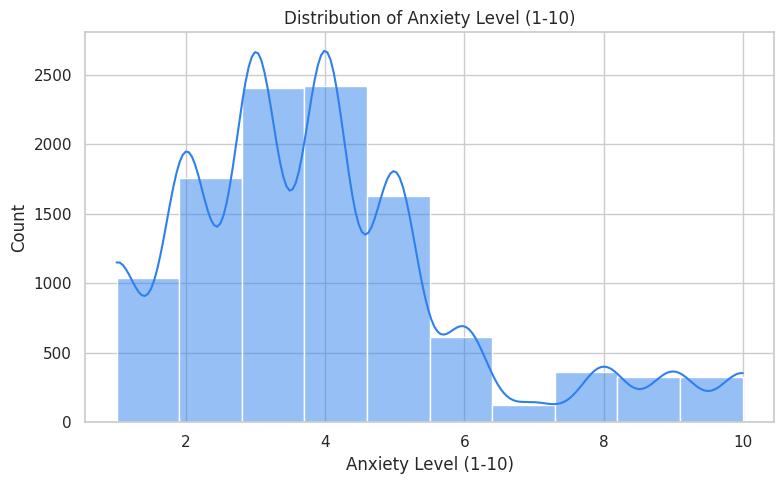

已輸出目標變數分佈圖：outputs/anxiety_level_distribution.png


In [21]:
# EDA 1：目標變數分佈直方圖
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET], bins=10, kde=True, color="#2f80ed")
plt.title("Distribution of Anxiety Level (1-10)")
plt.xlabel("Anxiety Level (1-10)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "anxiety_level_distribution.png", dpi=300)
plt.show()

print("已輸出目標變數分佈圖：outputs/anxiety_level_distribution.png")

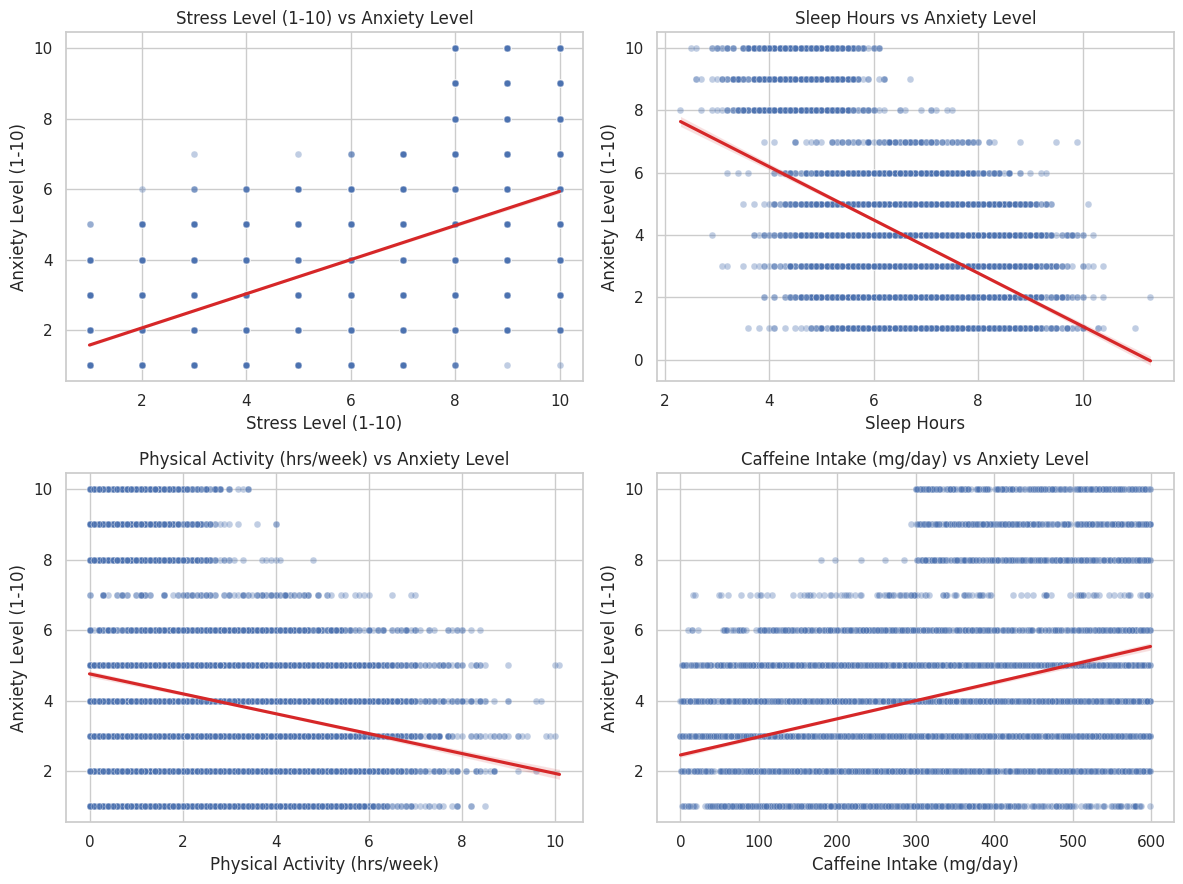

已輸出重要特徵散佈圖：outputs/important_feature_scatterplots.png


In [22]:
# EDA 2：重要特徵與焦慮等級的散佈圖
important_features = [
    "Stress Level (1-10)",
    "Sleep Hours",
    "Physical Activity (hrs/week)",
    "Caffeine Intake (mg/day)",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, feature in zip(axes, important_features):
    sns.scatterplot(data=df, x=feature, y=TARGET, alpha=0.35, s=24, ax=ax)
    sns.regplot(data=df, x=feature, y=TARGET, scatter=False, color="#d62728", ax=ax)
    ax.set_title(f"{feature} vs Anxiety Level")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "important_feature_scatterplots.png", dpi=300)
plt.show()

print("已輸出重要特徵散佈圖：outputs/important_feature_scatterplots.png")

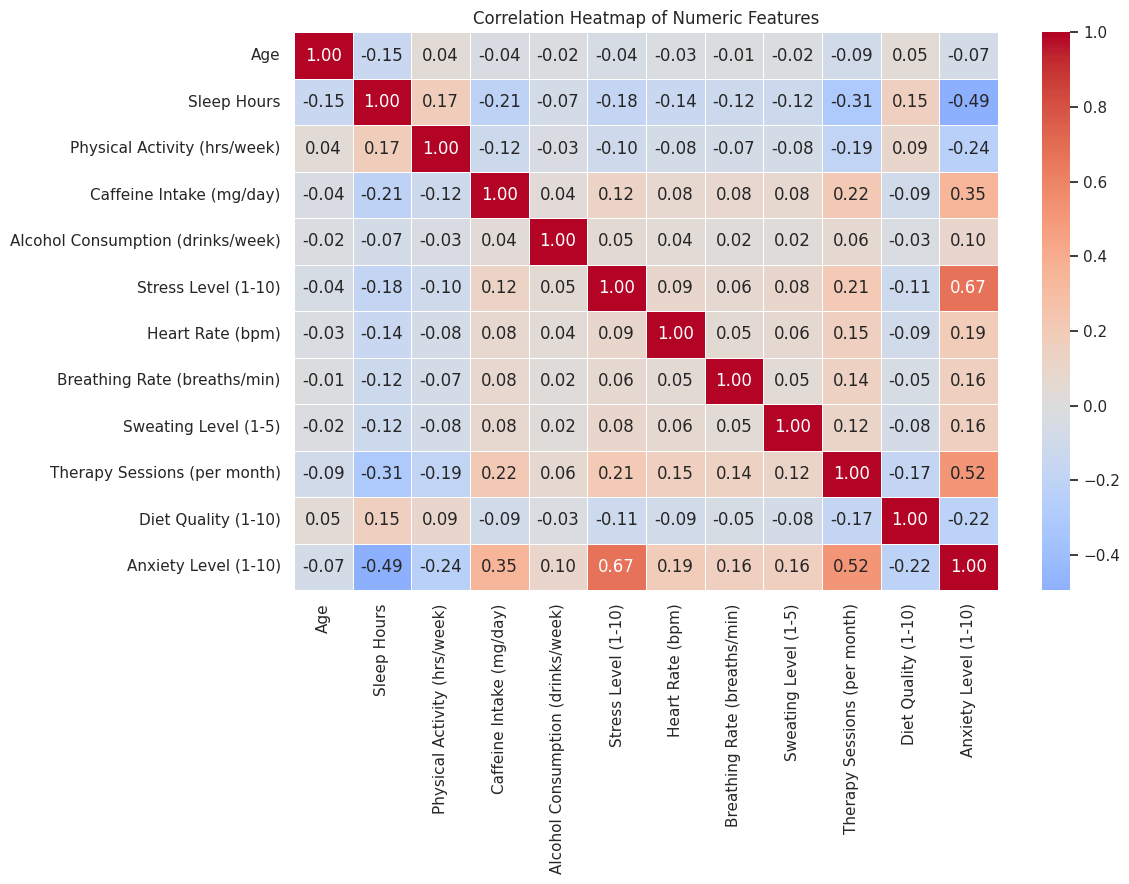

已輸出相關係數熱力圖：outputs/numeric_correlation_heatmap.png


In [23]:
# EDA 3：數值特徵相關係數熱力圖
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlation = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "numeric_correlation_heatmap.png", dpi=300)
plt.show()

print("已輸出相關係數熱力圖：outputs/numeric_correlation_heatmap.png")

資料理解初步觀察：資料共有 11,000 筆、19 個欄位，沒有缺失值。目標變數 `Anxiety Level (1-10)` 是 1 到 10 的焦慮程度分數。從相關係數與散佈圖可以初步觀察到，`Stress Level (1-10)`、`Caffeine Intake (mg/day)` 等變數與焦慮程度呈正向關係；`Sleep Hours`、`Physical Activity (hrs/week)` 則可能與焦慮程度呈負向關係。

## 3. Data Preparation (資料準備)

此階段依照新規格進行特徵工程、類別編碼、資料切分與標準化。新增的衍生變數包含：

- `Sleep_Activity_Score = Sleep Hours * Physical Activity (hrs/week)`
- `Stimulant_Index = Caffeine Intake (mg/day) + Alcohol Consumption (drinks/week) * 10`
- `Diet_Stimulant_Balance = Diet Quality (1-10) - (Stimulant_Index / 100)`

In [24]:
# 建立資料副本，避免直接改動原始 df
model_df = df.copy()

# 特徵工程：建立三個衍生變數
model_df["Sleep_Activity_Score"] = model_df["Sleep Hours"] * model_df["Physical Activity (hrs/week)"]
model_df["Stimulant_Index"] = model_df["Caffeine Intake (mg/day)"] + model_df["Alcohol Consumption (drinks/week)"] * 10
model_df["Diet_Stimulant_Balance"] = model_df["Diet Quality (1-10)"] - (model_df["Stimulant_Index"] / 100)

print("已建立衍生變數：Sleep_Activity_Score、Stimulant_Index、Diet_Stimulant_Balance")
display(model_df[["Sleep_Activity_Score", "Stimulant_Index", "Diet_Stimulant_Balance"]].head())

已建立衍生變數：Sleep_Activity_Score、Stimulant_Index、Diet_Stimulant_Balance


,Sleep_Activity_Score,Stimulant_Index,Diet_Stimulant_Balance
0,16.20,281,4.19
1,35.34,280,5.20
2,18.50,157,-0.57
3,16.24,420,-3.20
4,18.86,287,0.13


In [25]:
# 類別編碼：Yes/No 二元欄位轉為 1/0
binary_cols = [
    "Smoking",
    "Family History of Anxiety",
    "Dizziness",
    "Medication",
    "Recent Major Life Event",
]

for col in binary_cols:
    model_df[col] = model_df[col].map({"No": 0, "Yes": 1})

# Gender、Occupation 使用 pd.get_dummies 進行 One-Hot Encoding
model_df = pd.get_dummies(model_df, columns=["Gender", "Occupation"], drop_first=True, dtype=int)

print("二元變數已轉為 1/0，Gender 與 Occupation 已完成 One-Hot Encoding")
print("編碼後欄位數：", model_df.shape[1])
display(model_df.head())

二元變數已轉為 1/0，Gender 與 Occupation 已完成 One-Hot Encoding
編碼後欄位數： 34


,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,29,6.0,2.7,181,10,1,0,10,114,14,...,0,0,0,0,0,0,0,0,0,0
1,46,6.2,5.7,200,8,1,1,1,62,23,...,0,0,0,0,0,1,0,0,0,0
2,64,5.0,3.7,117,4,0,1,1,91,28,...,0,0,0,0,0,0,1,0,0,0
3,20,5.8,2.8,360,6,1,0,4,86,17,...,0,0,0,0,0,0,0,1,0,0
4,49,8.2,2.3,247,4,1,0,1,98,19,...,0,0,0,0,0,0,1,0,0,0


In [26]:
# 分割 X / y，並進行 80% / 20% train-test split
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# 使用 StandardScaler 對數值化後的所有 X 欄位進行標準化，方便比較線性迴歸係數大小
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("原始資料筆數：", len(model_df))
print("訓練集筆數：", len(X_train_scaled))
print("測試集筆數：", len(X_test_scaled))
print("模型輸入欄位數：", X_train_scaled.shape[1])

原始資料筆數： 11000
訓練集筆數： 8800
測試集筆數： 2200
模型輸入欄位數： 33


資料準備結論：原始資料的 19 個欄位經過三個衍生變數、二元編碼與 one-hot encoding 後，已全部轉為可放入線性回歸模型的數值型欄位。資料切分使用 `random_state=42`，確保結果可重現。

## 4. Modeling (建模)

本作業核心規定是使用 `sklearn.linear_model.LinearRegression`，因此以下三個模型皆使用 Linear Regression，不使用 Random Forest、Gradient Boosting 或其他非線性集成模型。

- Model 1：Baseline 基礎模型，使用所有數值化與轉換後變數。
- Model 2：Feature Selection，依據 Model 1 標準化後的係數絕對值，挑選前 10 個最重要變數重新訓練。
- Model 3：Interaction Terms，加入壓力與睡眠、壓力與咖啡因等交互作用項，建立進階線性模型。

In [27]:
# Model 1：Baseline，多元線性回歸使用所有轉換後欄位
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)
y_pred_1 = model_1.predict(X_test_scaled)

coef_model_1 = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": model_1.coef_,
})
coef_model_1["Abs_Coefficient"] = coef_model_1["Coefficient"].abs()
coef_model_1 = coef_model_1.sort_values("Abs_Coefficient", ascending=False)

print("Model 1 Baseline 訓練完成")
print("Model 1 係數絕對值前 10 名：")
display(coef_model_1.head(10))

Model 1 Baseline 訓練完成
Model 1 係數絕對值前 10 名：


,Feature,Coefficient,Abs_Coefficient
3,Caffeine Intake (mg/day),-1.951005e+12,1.951005e+12
17,Stimulant_Index,1.831932e+12,1.831932e+12
4,Alcohol Consumption (drinks/week),-7.678493e+11,7.678493e+11
18,Diet_Stimulant_Balance,-6.277114e+11,6.277114e+11
15,Diet Quality (1-10),5.325316e+11,5.325316e+11
2,Physical Activity (hrs/week),-1.144097e+00,1.144097e+00
7,Stress Level (1-10),1.101461e+00,1.101461e+00
16,Sleep_Activity_Score,1.095584e+00,1.095584e+00
1,Sleep Hours,-8.135087e-01,8.135087e-01
13,Therapy Sessions (per month),4.987508e-01,4.987508e-01


In [28]:
# Model 2：依據 Model 1 係數絕對值挑選前 10 個重要變數
top_10_features = coef_model_1.head(10)["Feature"].tolist()

model_2 = LinearRegression()
model_2.fit(X_train_scaled[top_10_features], y_train)
y_pred_2 = model_2.predict(X_test_scaled[top_10_features])

coef_model_2 = pd.DataFrame({
    "Feature": top_10_features,
    "Coefficient": model_2.coef_,
})
coef_model_2["Abs_Coefficient"] = coef_model_2["Coefficient"].abs()
coef_model_2 = coef_model_2.sort_values("Abs_Coefficient", ascending=False)

print("Model 2 Feature Selection 訓練完成")
print("選出的前 10 個重要變數：")
for feature in top_10_features:
    print("-", feature)

display(coef_model_2)

Model 2 Feature Selection 訓練完成
選出的前 10 個重要變數：
- Caffeine Intake (mg/day)
- Stimulant_Index
- Alcohol Consumption (drinks/week)
- Diet_Stimulant_Balance
- Diet Quality (1-10)
- Physical Activity (hrs/week)
- Stress Level (1-10)
- Sleep_Activity_Score
- Sleep Hours
- Therapy Sessions (per month)


,Feature,Coefficient,Abs_Coefficient
5,Physical Activity (hrs/week),-1.333769,1.333769
7,Sleep_Activity_Score,1.284978,1.284978
6,Stress Level (1-10),1.115854,1.115854
8,Sleep Hours,-0.873519,0.873519
9,Therapy Sessions (per month),0.512984,0.512984
0,Caffeine Intake (mg/day),0.153069,0.153069
1,Stimulant_Index,0.138968,0.138968
3,Diet_Stimulant_Balance,-0.085858,0.085858
4,Diet Quality (1-10),-0.025865,0.025865
2,Alcohol Consumption (drinks/week),-0.005129,0.005129


In [29]:
# Model 3：加入合理交互作用項後重新訓練線性模型
interaction_df = model_df.copy()
interaction_df["Stress_x_Sleep"] = interaction_df["Stress Level (1-10)"] * interaction_df["Sleep Hours"]
interaction_df["Stress_x_Caffeine"] = interaction_df["Stress Level (1-10)"] * interaction_df["Caffeine Intake (mg/day)"]
interaction_df["Stress_x_PhysicalActivity"] = interaction_df["Stress Level (1-10)"] * interaction_df["Physical Activity (hrs/week)"]
interaction_df["Sleep_x_DietQuality"] = interaction_df["Sleep Hours"] * interaction_df["Diet Quality (1-10)"]

X_interaction = interaction_df.drop(columns=[TARGET])
y_interaction = interaction_df[TARGET]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interaction,
    y_interaction,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

interaction_scaler = StandardScaler()
X_train_i_scaled = pd.DataFrame(
    interaction_scaler.fit_transform(X_train_i),
    columns=X_train_i.columns,
    index=X_train_i.index,
)
X_test_i_scaled = pd.DataFrame(
    interaction_scaler.transform(X_test_i),
    columns=X_test_i.columns,
    index=X_test_i.index,
)

model_3 = LinearRegression()
model_3.fit(X_train_i_scaled, y_train_i)
y_pred_3 = model_3.predict(X_test_i_scaled)

coef_model_3 = pd.DataFrame({
    "Feature": X_train_i_scaled.columns,
    "Coefficient": model_3.coef_,
})
coef_model_3["Abs_Coefficient"] = coef_model_3["Coefficient"].abs()
coef_model_3 = coef_model_3.sort_values("Abs_Coefficient", ascending=False)

print("Model 3 Interaction Terms 訓練完成")
print("加入的交互作用項：Stress_x_Sleep、Stress_x_Caffeine、Stress_x_PhysicalActivity、Sleep_x_DietQuality")
display(coef_model_3.head(15))

Model 3 Interaction Terms 訓練完成
加入的交互作用項：Stress_x_Sleep、Stress_x_Caffeine、Stress_x_PhysicalActivity、Sleep_x_DietQuality


,Feature,Coefficient,Abs_Coefficient
7,Stress Level (1-10),1.800779,1.800779
16,Sleep_Activity_Score,0.761583,0.761583
33,Stress_x_Sleep,-0.739809,0.739809
36,Sleep_x_DietQuality,0.711810,0.711810
2,Physical Activity (hrs/week),-0.646561,0.646561
1,Sleep Hours,-0.630530,0.630530
13,Therapy Sessions (per month),0.426629,0.426629
15,Diet Quality (1-10),-0.422456,0.422456
18,Diet_Stimulant_Balance,-0.362003,0.362003
34,Stress_x_Caffeine,0.273620,0.273620


建模結論：三個模型皆符合多元線性回歸要求。Model 1 使用所有轉換後特徵；Model 2 使用 Model 1 係數大小選出的前 10 個重要特徵；Model 3 額外加入交互作用項，用來檢查睡眠、咖啡因與運動是否會改變壓力對焦慮程度的影響。

## 5. Evaluation (評估)

此階段分別計算 Model 1、Model 2、Model 3 的 R2、MAE、RMSE，並繪製含 95% confidence interval 的預測圖。

In [30]:
# 評估函式：計算 R2、MAE、RMSE
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

metrics_df = pd.DataFrame([
    {"Model": "Model 1 Baseline", **regression_metrics(y_test, y_pred_1)},
    {"Model": "Model 2 Feature Selection", **regression_metrics(y_test, y_pred_2)},
    {"Model": "Model 3 Interaction Terms", **regression_metrics(y_test_i, y_pred_3)},
])

metrics_df.to_csv(OUTPUT_DIR / "model_evaluation_metrics.csv", index=False)

print("三個模型評估結果：")
display(metrics_df)
print("已輸出模型評估表：outputs/model_evaluation_metrics.csv")

三個模型評估結果：


,Model,R2,MAE,RMSE
0,Model 1 Baseline,0.734041,0.880994,1.110120
1,Model 2 Feature Selection,0.727553,0.893405,1.123579
2,Model 3 Interaction Terms,0.744755,0.870597,1.087530


已輸出模型評估表：outputs/model_evaluation_metrics.csv


In [31]:
# 選擇 R2 最高的模型作為繪圖與結論主模型
predictions = {
    "Model 1 Baseline": (y_test, y_pred_1),
    "Model 2 Feature Selection": (y_test, y_pred_2),
    "Model 3 Interaction Terms": (y_test_i, y_pred_3),
}

best_model_name = metrics_df.sort_values("R2", ascending=False).iloc[0]["Model"]
best_y_test, best_y_pred = predictions[best_model_name]

print("R2 最高的模型：", best_model_name)

R2 最高的模型： Model 3 Interaction Terms


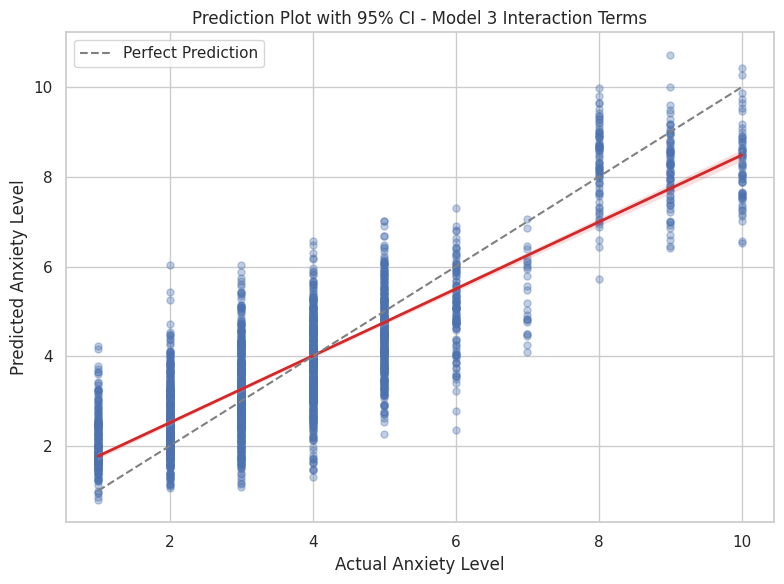

已輸出含 95% 信賴區間的預測圖：outputs/prediction_plot_with_ci.png


In [32]:
# 預測圖與 95% Confidence Interval
plot_df = pd.DataFrame({
    "Actual Anxiety Level": best_y_test,
    "Predicted Anxiety Level": best_y_pred,
})

plt.figure(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="Actual Anxiety Level",
    y="Predicted Anxiety Level",
    ci=95,
    scatter_kws={"alpha": 0.35, "s": 26},
    line_kws={"color": "#d62728", "linewidth": 2},
)
plt.plot([1, 10], [1, 10], linestyle="--", color="gray", label="Perfect Prediction")
plt.title(f"Prediction Plot with 95% CI - {best_model_name}")
plt.xlabel("Actual Anxiety Level")
plt.ylabel("Predicted Anxiety Level")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prediction_plot_with_ci.png", dpi=300)
plt.show()

print("已輸出含 95% 信賴區間的預測圖：outputs/prediction_plot_with_ci.png")

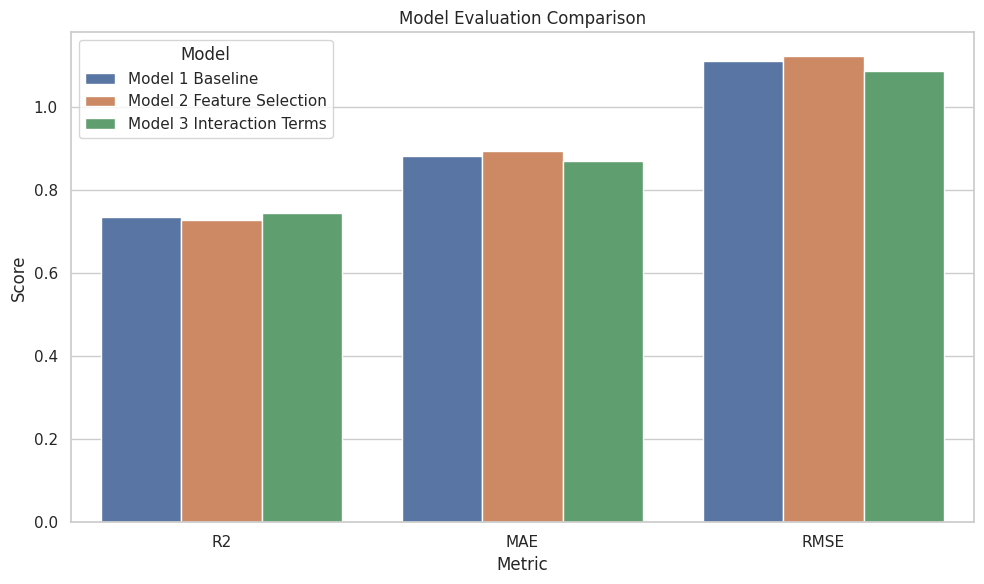

已輸出模型比較圖：outputs/model_evaluation_comparison.png


In [33]:
# 額外繪製三個模型的 R2、MAE、RMSE 比較圖，方便報告比較
metrics_long = metrics_df.melt(id_vars="Model", value_vars=["R2", "MAE", "RMSE"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model")
plt.title("Model Evaluation Comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_evaluation_comparison.png", dpi=300)
plt.show()

print("已輸出模型比較圖：outputs/model_evaluation_comparison.png")

評估結論：本作業以 R2、MAE、RMSE 比較三個 LinearRegression 模型。若 Model 3 的 R2 較高，代表交互作用項有助於提升解釋力；若 Model 2 與 Model 1 表現接近，則代表使用較少重要特徵也能保留大部分預測能力。預測圖使用 `seaborn.regplot(ci=95)` 呈現回歸線與 95% confidence interval，符合指定輸出要求。

## 6. Deployment (部署與結論)

根據回歸係數方向可以整理模型結論。一般而言，`Stress Level (1-10)`、`Caffeine Intake (mg/day)`、`Therapy Sessions (per month)` 等變數若係數為正，表示其增加時焦慮分數也傾向提高；`Sleep Hours`、`Physical Activity (hrs/week)`、`Diet Quality (1-10)` 若係數為負，表示較好的睡眠、運動與飲食品質可能與較低焦慮程度相關。

實際應用上，此模型可作為心理健康機構、校園輔導單位或健康管理系統的初步風險篩檢輔助工具。透過生活型態與生理數據，模型可以協助辨識可能需要進一步關注的族群。不過，本模型只適合資料分析與初步輔助判斷，不能取代專業心理諮商或醫療診斷。

In [34]:
# 輸出最佳模型的重要係數方向，作為 Deployment 結論依據
if best_model_name == "Model 1 Baseline":
    final_coef_df = coef_model_1.copy()
elif best_model_name == "Model 2 Feature Selection":
    final_coef_df = coef_model_2.copy()
else:
    final_coef_df = coef_model_3.copy()

print("最佳模型：", best_model_name)
print("正向影響最大的前 10 個變數：")
display(final_coef_df.sort_values("Coefficient", ascending=False).head(10))

print("負向影響最大的前 10 個變數：")
display(final_coef_df.sort_values("Coefficient", ascending=True).head(10))

最佳模型： Model 3 Interaction Terms
正向影響最大的前 10 個變數：


,Feature,Coefficient,Abs_Coefficient
7,Stress Level (1-10),1.800779,1.800779
16,Sleep_Activity_Score,0.761583,0.761583
36,Sleep_x_DietQuality,0.711810,0.711810
13,Therapy Sessions (per month),0.426629,0.426629
34,Stress_x_Caffeine,0.273620,0.273620
8,Heart Rate (bpm),0.051666,0.051666
10,Sweating Level (1-5),0.045940,0.045940
9,Breathing Rate (breaths/min),0.036325,0.036325
5,Smoking,0.032184,0.032184
11,Dizziness,0.020865,0.020865


負向影響最大的前 10 個變數：


,Feature,Coefficient,Abs_Coefficient
33,Stress_x_Sleep,-0.739809,0.739809
2,Physical Activity (hrs/week),-0.646561,0.646561
1,Sleep Hours,-0.630530,0.630530
15,Diet Quality (1-10),-0.422456,0.422456
18,Diet_Stimulant_Balance,-0.362003,0.362003
35,Stress_x_PhysicalActivity,-0.224041,0.224041
24,Occupation_Engineer,-0.083395,0.083395
0,Age,-0.068432,0.068432
30,Occupation_Scientist,-0.062387,0.062387
26,Occupation_Lawyer,-0.048449,0.048449


## GPT 輔助內容

本作業使用 GPT / Code Agent 協助整理 HW3 規格、規劃 CRISP-DM 流程、撰寫 Jupyter Notebook 程式碼、設計特徵工程、建立多元線性回歸模型、產生圖表與整理報告文字。最終報告需將 GPT 輔助內容清楚標示，並可搭配 `.agent/records/CHAT_LOG.md` 作為對話紀錄摘要。

## NotebookLM 摘要

【NotebookLM 研究摘要：多元線性回歸應用於社交焦慮預測】
本摘要探討網路上針對「社交焦慮與生活型態」主題的主流預測解法。在 Kaggle 平台上，許多解法傾向使用隨機森林或梯度提升樹等複雜演算法以追求高準確度（例如梯度提升模型 R² 可達 0.778）
。然而，為了提升模型的「可解釋性」，本研究聚焦於多元線性回歸的應用
。
資料分析顯示，壓力等級、睡眠時數與治療頻率是影響焦慮程度的最核心特徵
。網路上更優的線性回歸解法並非盲目放入所有變數，而是強調進行嚴謹的「特徵選擇」，並進一步引入「交互作用項」（例如：壓力 × 睡眠時數），藉此深入探討睡眠是否能緩衝壓力對焦慮造成的影響
。
綜合而言，結合特徵選擇與合理交互作用項的進階多元線性回歸，不僅能將模型解釋力（R²）從單純加法模型的 0.679 有效提升至 0.710
，更能明確揭示各變數的影響方向（如壓力呈正相關、充足睡眠呈負相關）
。此作法在保持模型透明度的同時，非常適合實際應用於心理健康機構的初步風險篩檢
。